Basic Player Information:

- Player– Player's name
- Nation – Player's nationality
- Pos – Position (FW, MF, DF, GK)
- Squad – Club name
- Comp – League
- Age – Age of the player
- Born – Year of birth

Playing Time & Appearances:

- MP – Matches played
- Starts – Games started
- Min – Minutes played
- 90s – Number of full
- 90 - minute matches played

Attacking Stats:

- Gls – Goals scored
- Ast – Assists provided
- G+A – Goals + Assists
- xG – Expected goals
- xAG – Expected assists
- npxG – Non-penalty expected goals
- G-PK – Goals excluding penalties

Defensive Stats:

- Tkl – Total tackles
- TklW – Tackles won
- Blocks – Blocks made
- Int – Interceptions
- Tkl+Int – Combined tackles and interceptions
- Clr – Clearances
- Err – Errors leading to goals

Passing & Creativity Stats:

- PrgP – Progressive passes
- PrgC – Progressive carries
- KP – Key passes (passes leading to a shot)
- Cmp%_stats_passing – Pass completion percentage
- Ast_stats_passing – Assists
- xA – Expected assists
- PPA – Passes into the penalty area

Goalkeeping Stats:

- GA – Goals conceded
- Saves – Saves made
- Save% – Save percentage
- CS – Clean sheets
- CS% – Clean sheet percentage
- PKA – Penalties faced
- PKsv – Penalty saves

Possession & Ball Control:

- Touches – Total touches of the ball
- Carries – Total ball carries
- PrgR – Progressive runs (carries moving the ball forward significantly)
- Mis – Miscontrols
- Dis – Times dispossessed

Miscellaneous Stats:

- CrdY – Yellow cards
- CrdR – Red cards
- PKwon – Penalties won
- PKcon – Penalties conceded
- Recov – Ball recoveries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from jedi.api.refactoring import rename
from pandas.core.groupby import groupby

In [2]:
players_df = pd.read_csv("data/players_data_light-2025_2026.csv")
players_df.head()

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jerome Abbey,eng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Zach Abbott,eng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
players_df.shape

(2839, 53)

In [4]:
# Fix doubled ages

players_df.loc[
    players_df["Age"] > 45,
    "Age"
] = players_df.loc[
    players_df["Age"] > 45, "Age"
] / 2


# Keep only first repeated nation code
players_df["Nation"] = (
    players_df["Nation"]
    .astype(str)
    .str.extract(r"([a-z]{2}\s[A-Z]{3})")[0]
)

players_df["Pos"] = (
    players_df["Pos"]
    .str.replace("FWFW", "FW", regex= False)
    .str.replace("MFMF", "MF", regex= False)
    .str.replace("DFDF", "DF", regex= False)
    .str.replace("GKGK", "GK", regex= False)
)

In [5]:
players_df.head(5)

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
0,1,Brenden Aaronson,us USA,"MF,FW",Leeds United,eng Premier League,24.0,2000.0,37,30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,Jerome Abbey,ng ENG,MF,Wolves,eng Premier League,15.0,2009.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,Zach Abbott,ng ENG,DF,Nottingham Forest,eng Premier League,19.0,2006.0,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,Jones El-Abdellaoui,ma MAR,"MF,FW",Celta Vigo,es La Liga,19.0,2006.0,22,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,Himad Abdelli,dz ALG,MF,Marseille,fr Ligue 1,25.0,1999.0,8,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Convert the numbers correctly
numeric_columns = ["Age", "MP", "Gls", "Ast", "Born"]

for col in numeric_columns:
    players_df[col] = pd.to_numeric(
        players_df[col],
        errors="coerce"
    )

players_df["Age"] = players_df["Age"].astype("Int64")
players_df["Born"] = players_df["Born"].astype("Int64")

In [7]:
players_df["Age"].dtype

Int64Dtype()

# Premier League Info

In [8]:
chelsea_squad = players_df[
    players_df["Squad"].str.contains("Chelsea")
]
chelsea_squad


,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
21,22,Joshua Acheampong,ng ENG,DF,Chelsea,eng Premier League,19,2006,17,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,27,Tosin Adarabioyo,ng ENG,DF,Chelsea,eng Premier League,27,1997,16,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
187,188,Benoît Badiashile,fr FRA,DF,Chelsea,eng Premier League,24,2001,8,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
401,402,Facundo Buonanotte,ar ARG,MF,Chelsea,eng Premier League,20,2004,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
425,426,Moisés Caicedo,ec ECU,MF,Chelsea,eng Premier League,23,2001,33,32,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
517,518,Trevoh Chalobah,ng ENG,DF,Chelsea,eng Premier League,26,1999,34,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
563,564,Levi Colwill,ng ENG,DF,Chelsea,eng Premier League,22,2003,3,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
612,613,Marc Cucurella,es ESP,DF,Chelsea,eng Premier League,27,1998,34,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
661,662,Liam Delap,ng ENG,FW,Chelsea,eng Premier League,22,2003,28,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
676,677,Jesse Derry,ng ENG,MF,Chelsea,eng Premier League,18,2007,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
chelsea_goal_scores = (
    players_df[
        players_df["Squad"].str.contains("Chelsea")
    ][["Player", "Squad", "Gls", "Ast", "MP"]]
    .sort_values("Gls", ascending=False)
    .reset_index(drop=True)
)
chelsea_goal_scores

,Player,Squad,Gls,Ast,MP
0,João Pedro,Chelsea,15,5,35
1,Enzo Fernández,Chelsea,10,4,36
2,Cole Palmer,Chelsea,10,1,26
3,Pedro Neto,Chelsea,5,6,34
4,Trevoh Chalobah,Chelsea,3,0,34
5,Moisés Caicedo,Chelsea,3,1,33
6,Malo Gusto,Chelsea,2,3,34
7,Reece James,Chelsea,2,4,29
8,Estêvão Willian,Chelsea,2,2,22
9,Andrey Santos,Chelsea,1,0,27


In [10]:
chelsea_goal_scores = players_df[
    players_df["Squad"].str.contains("Chelsea")
].copy()

chelsea_goal_scores["Goals per 90"] =(
    chelsea_goal_scores["Gls"] / chelsea_goal_scores["Min"] * 90
)
chelsea_goal_scores[["Player", "Squad", "Gls", "Min", "Goals per 90"]]

,Player,Squad,Gls,Min,Goals per 90
21,Joshua Acheampong,Chelsea,1,666,0.135135
26,Tosin Adarabioyo,Chelsea,0,795,0.000000
187,Benoît Badiashile,Chelsea,0,471,0.000000
401,Facundo Buonanotte,Chelsea,0,45,0.000000
425,Moisés Caicedo,Chelsea,3,2795,0.096601
517,Trevoh Chalobah,Chelsea,3,2783,0.097018
563,Levi Colwill,Chelsea,0,225,0.000000
612,Marc Cucurella,Chelsea,1,2707,0.033247
661,Liam Delap,Chelsea,1,1107,0.081301
676,Jesse Derry,Chelsea,0,44,0.000000


In [11]:
chelsea_goal_scores = chelsea_goal_scores.sort_values(
    by= "Goals per 90", ascending= False
).reset_index(drop=True)
chelsea_goal_scores[[
    "Player", "Squad", "Gls", "Min", "Goals per 90"]]

,Player,Squad,Gls,Min,Goals per 90
0,João Pedro,Chelsea,15,2661,0.507328
1,Cole Palmer,Chelsea,10,1955,0.460358
2,Enzo Fernández,Chelsea,10,3115,0.288925
3,Estêvão Willian,Chelsea,2,848,0.212264
4,Pedro Neto,Chelsea,5,2631,0.171038
5,Joshua Acheampong,Chelsea,1,666,0.135135
6,Trevoh Chalobah,Chelsea,3,2783,0.097018
7,Moisés Caicedo,Chelsea,3,2795,0.096601
8,Reece James,Chelsea,2,1963,0.091696
9,Liam Delap,Chelsea,1,1107,0.081301


In [12]:
chelsea_squad = players_df[
    players_df["Squad"].str.contains("Chelsea")
].copy()


chelsea_squad["Red Cards per 90"] = (
    chelsea_squad["CrdR"] / chelsea_squad["Min"] * 90
)

chelsea_red_cards = chelsea_squad.sort_values(
    by= "Red Cards per 90",
    ascending= False
).reset_index(drop=True)

chelsea_squad["Yellow Cards per 90"] = (
    chelsea_squad["CrdY"] / chelsea_squad["Min"] * 90
)

chelsea_yellow_cards = chelsea_squad.sort_values(
    by= "Yellow Cards per 90",
    ascending= False
)


In [13]:
chelsea_red_cards[["Player", "Squad", "CrdR", "Min", "Red Cards per 90"]]

,Player,Squad,CrdR,Min,Red Cards per 90
0,Wesley Fofana,Chelsea,2,1722,0.104530
1,Malo Gusto,Chelsea,1,2261,0.039805
2,Pedro Neto,Chelsea,1,2631,0.034208
3,Marc Cucurella,Chelsea,1,2707,0.033247
4,Trevoh Chalobah,Chelsea,1,2783,0.032339
5,Moisés Caicedo,Chelsea,1,2795,0.032200
6,Robert Sánchez,Chelsea,1,3039,0.029615
7,Benoît Badiashile,Chelsea,0,471,0.000000
8,Liam Delap,Chelsea,0,1107,0.000000
9,Levi Colwill,Chelsea,0,225,0.000000


In [14]:
chelsea_yellow_cards[["Player", "Squad", "CrdY", "Min", "Yellow Cards per 90"]]

,Player,Squad,CrdY,Min,Yellow Cards per 90
839,Dario Essugo,Chelsea,2,30,6.000000
979,Tyrique George,Chelsea,2,145,1.241379
1128,Jorrel Hato,Chelsea,7,1148,0.548780
901,Wesley Fofana,Chelsea,9,1722,0.470383
2762,Estêvão Willian,Chelsea,4,848,0.424528
187,Benoît Badiashile,Chelsea,2,471,0.382166
425,Moisés Caicedo,Chelsea,11,2795,0.354204
1090,Marc Guiu,Chelsea,1,257,0.350195
661,Liam Delap,Chelsea,4,1107,0.325203
877,Enzo Fernández,Chelsea,10,3115,0.288925


In [15]:
# #Goalkeeping Stats:
#
# - GA – Goals conceded
# - Saves – Saves made
# - Save% – Save percentage
# - CS – Clean sheets
# - CS% – Clean sheet percentage
# - PKA – Penalties faced
# - PKsv – Penalty saves

In [16]:
chelsea_squad = (
    players_df[
        players_df["Squad"].str.contains("Chelsea")
    ].copy()
)
chelsea_goal_keepers = (
    chelsea_squad[
        chelsea_squad["Pos"] == "GK"
    ]
)

chelsea_goal_keepers_goals_conceded = chelsea_goal_keepers.sort_values(
    by= ["GA", "CS", "PKA", "PKsv"],
    ascending= False
).reset_index(drop= True)
chelsea_goal_keepers_goals_conceded[["Player", "Squad", "MP", "Min", "GA", "CS", "PKA", "PKsv"]]


,Player,Squad,MP,Min,GA,CS,PKA,PKsv
0,Robert Sánchez,Chelsea,35,3039,49.0,9.0,2.0,0.0
1,Filip Jørgensen,Chelsea,5,379,5.0,0.0,0.0,0.0


In [17]:
chelsea_goal_keepers

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
1291,1292,Filip Jørgensen,dk DEN,GK,Chelsea,eng Premier League,23,2002,5,3,...,61.5,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2338,2339,Robert Sánchez,es ESP,GK,Chelsea,eng Premier League,27,1997,35,35,...,67.6,13.0,8.0,14.0,9.0,25.7,2.0,2.0,0.0,0.0


In [18]:
players_df.Pos.value_counts()

Pos
MF       922
DF       705
FW       398
MF,FW    217
GK       194
FW,MF    144
DF,MF    141
MF,DF    115
DF,FW      3
Name: count, dtype: int64

In [19]:
english_teams = (
    players_df[
        players_df["Comp"].str.contains("eng")
    ].copy()
)

english_teams_red_cards = english_teams.sort_values(
    by= ["Squad", "CrdR"],
    ascending= False
).reset_index(drop=True)


english_teams_red_cards[["Player", "Squad", "CrdR"]]


,Player,Squad,CrdR
0,Emmanuel Agbadou,Wolves,1
1,Toti Gomes,Wolves,1
2,Ladislav Krejčí,Wolves,1
3,Jerome Abbey,Wolves,0
4,André,Wolves,0
...,...,...,...
546,Jurriën Timber,Arsenal,0
547,Leandro Trossard,Arsenal,0
548,Ben White,Arsenal,0
549,Martín Zubimendi,Arsenal,0


In [20]:
english_teams_red_cards = (
    english_teams
    .groupby("Squad", as_index=False)["CrdR"]
    .sum()
    .sort_values(by="CrdR", ascending=False)
    .reset_index(drop=True)
)

english_teams_red_cards

,Squad,CrdR
0,Chelsea,8
1,Everton,4
2,Tottenham Hotspur,4
3,Burnley,3
4,Wolves,3
5,Sunderland,3
6,Manchester Utd,3
7,West Ham United,3
8,Newcastle United,3
9,Crystal Palace,2


In [21]:
english_teams_yellow_cards = (
    english_teams
    .groupby("Squad", as_index= False)["CrdY"]
    .sum()
    .sort_values(by= "CrdY", ascending= False)
    .reset_index(drop=True)
)

english_teams_yellow_cards

,Squad,CrdY
0,Tottenham Hotspur,101
1,Chelsea,98
2,Bournemouth,88
3,Brighton,86
4,Sunderland,82
5,Wolves,80
6,Crystal Palace,76
7,Fulham,75
8,Everton,74
9,West Ham United,69


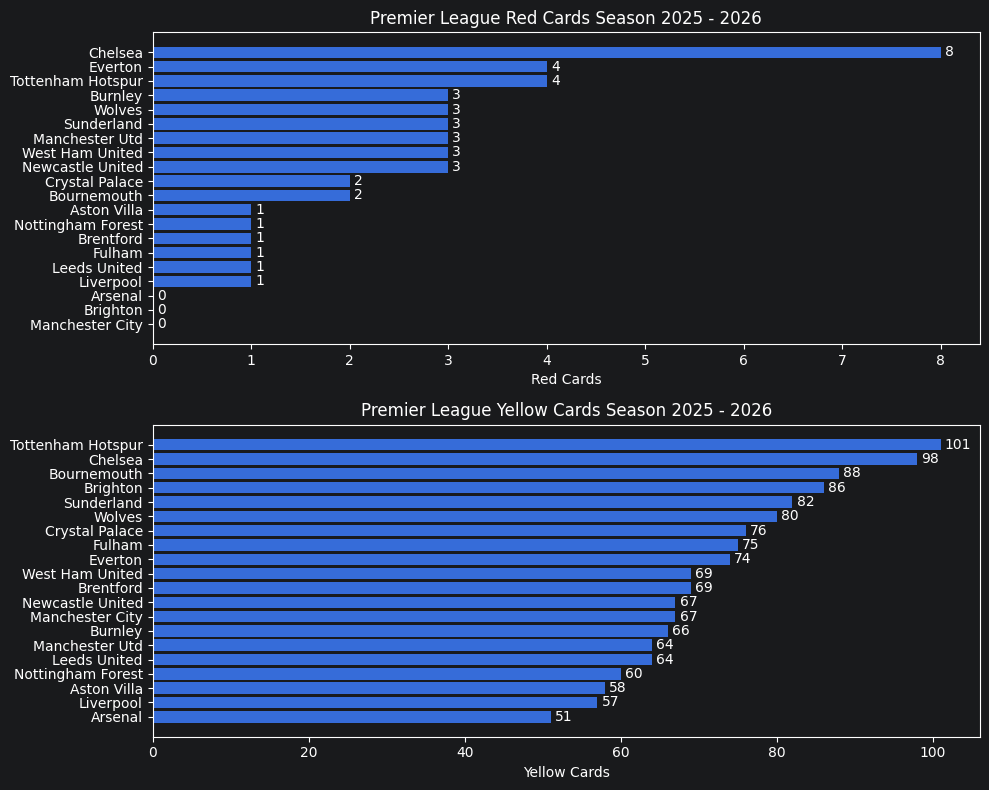

In [22]:
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
ax1 = plt.gca()

bars1 = ax1.barh(
    english_teams_red_cards["Squad"],
    english_teams_red_cards["CrdR"]
)

ax1.set_title("Premier League Red Cards Season 2025 - 2026")
ax1.set_xlabel("Red Cards")
ax1.bar_label(bars1, padding=3)
ax1.invert_yaxis()


plt.subplot(2, 1, 2)
ax2 = plt.gca()

bars2 = ax2.barh(
    english_teams_yellow_cards["Squad"],
    english_teams_yellow_cards["CrdY"]
)

ax2.set_title("Premier League Yellow Cards Season 2025 - 2026")
ax2.set_xlabel("Yellow Cards")
ax2.bar_label(bars2, padding=3)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

In [23]:
english_teams_yellow_cards_per_game = (
    english_teams
    .groupby("Squad")
    .agg({
        "CrdY": "sum",
        "MP": "max"
    })
)

english_teams_yellow_cards_per_game["Yellow Cards per Game"] = (
    english_teams_yellow_cards_per_game["CrdY"] / english_teams_yellow_cards_per_game["MP"]
)

english_teams_yellow_cards_per_game = (
    english_teams_yellow_cards_per_game
    .sort_values("Yellow Cards per Game", ascending= False)
)

english_teams_yellow_cards_per_game

,CrdY,MP,Yellow Cards per Game
Squad,,,
Tottenham Hotspur,101,35,2.885714
Chelsea,98,36,2.722222
Bournemouth,88,38,2.315789
Wolves,80,35,2.285714
Brighton,86,38,2.263158
Sunderland,82,38,2.157895
Crystal Palace,76,38,2.000000
Fulham,75,38,1.973684
Everton,74,38,1.947368


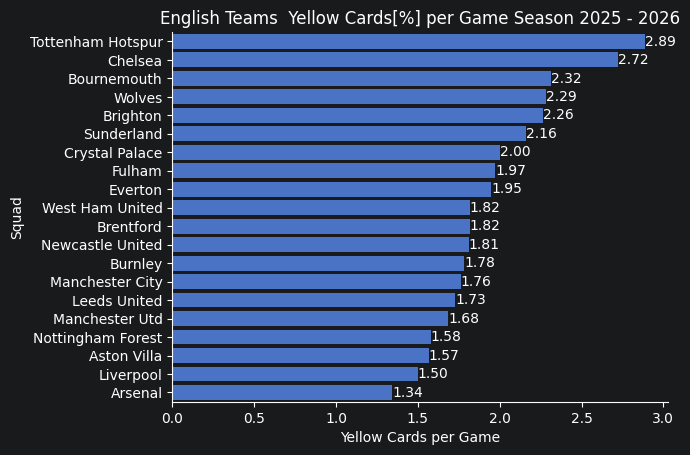

In [24]:
ax = sns.barplot(data= english_teams_yellow_cards_per_game,
            x= "Yellow Cards per Game",
            y= "Squad",)

for container in ax.containers:
    ax.bar_label(container, fmt= "%.2f")

plt.title("English Teams  Yellow Cards[%] per Game Season 2025 - 2026")
sns.despine()
plt.show()

In [25]:
english_teams_saves = (
    english_teams
    .groupby("Squad", as_index= False)["Saves"]
    .sum()
    .sort_values("Saves", ascending= False)
    .reset_index(drop= True)
)

english_teams_saves

,Squad,Saves
0,Burnley,137.0
1,West Ham United,129.0
2,Sunderland,118.0
3,Aston Villa,114.0
4,Newcastle United,113.0
5,Wolves,111.0
6,Bournemouth,109.0
7,Crystal Palace,107.0
8,Nottingham Forest,107.0
9,Brentford,106.0


In [26]:
english_teams_goalkeeper_clean_sheets = (
    english_teams
    .groupby("Squad", as_index= False)["CS"]
    .sum()
    .sort_values("CS", ascending= False)
    .reset_index(drop= True)
)
english_teams_goalkeeper_clean_sheets

,Squad,CS
0,Arsenal,19.0
1,Manchester City,16.0
2,Crystal Palace,12.0
3,Bournemouth,11.0
4,Sunderland,11.0
5,Everton,11.0
6,Brentford,10.0
7,Aston Villa,10.0
8,Liverpool,10.0
9,Brighton,10.0


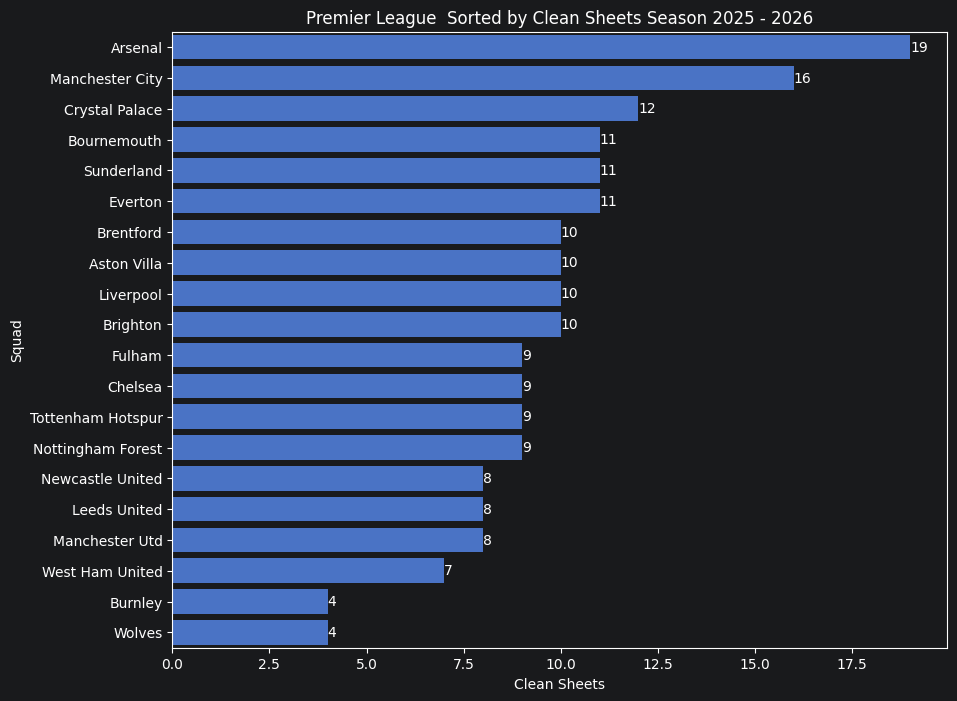

In [27]:
plt.figure(figsize= (10, 8))

ax = sns.barplot(
    data= english_teams_goalkeeper_clean_sheets,
    y= "Squad",
    x= "CS",
)

for container in ax.containers:
    ax.bar_label(container)


plt.title("Premier League  Sorted by Clean Sheets Season 2025 - 2026")
plt.xlabel("Clean Sheets")
plt.ylabel("Squad")

plt.show()

In [28]:
chelsea_squad.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

In [29]:
chelsea_squad_ages = (
    chelsea_squad
    .groupby("Player", as_index= False)["Age"]
    .sum()
    .sort_values("Age", ascending= False)
    .reset_index(drop= True)
)

chelsea_squad_ages

,Player,Age
0,Robert Sánchez,27
1,Marc Cucurella,27
2,Tosin Adarabioyo,27
3,Trevoh Chalobah,26
4,Pedro Neto,25
5,Reece James,25
6,Enzo Fernández,24
7,Wesley Fofana,24
8,Benoît Badiashile,24
9,Moisés Caicedo,23


In [30]:
chelsea_squad_mean_player_age = chelsea_squad_ages["Age"].mean()
print(f"Chelsea average age: {chelsea_squad_mean_player_age:.2f}")

Chelsea average age: 21.93


In [31]:
english_teams_total_ages = (
    english_teams
    .groupby("Squad", as_index= False)["Age"]
    .sum()
    .sort_values("Age", ascending= False)
    .reset_index(drop= True)
)

english_teams_total_ages

,Squad,Age
0,West Ham United,808
1,Nottingham Forest,784
2,Aston Villa,776
3,Wolves,773
4,Crystal Palace,748
5,Tottenham Hotspur,736
6,Burnley,722
7,Sunderland,698
8,Brighton,684
9,Newcastle United,674


In [32]:
english_teams_mean_ages = (
    english_teams
    .groupby("Squad", as_index= False)["Age"]
    .mean()
    .sort_values("Age", ascending= True)
    .reset_index(drop= True)
)

english_teams_mean_ages

,Squad,Age
0,Chelsea,21.933333
1,Tottenham Hotspur,23.741935
2,Manchester Utd,23.814815
3,Bournemouth,23.961538
4,Sunderland,24.068966
5,Brighton,24.428571
6,Brentford,24.461538
7,Manchester City,24.481481
8,Crystal Palace,24.933333
9,Wolves,24.935484


In [33]:
english_teams_players_count = (
    english_teams["Squad"]
    .value_counts()
    .reset_index()
)

english_teams_players_count.columns = ["Squad", "Number of Players"]

english_teams_players_count

,Squad,Number of Players
0,West Ham United,32
1,Wolves,31
2,Nottingham Forest,31
3,Tottenham Hotspur,31
4,Aston Villa,30
5,Chelsea,30
6,Crystal Palace,30
7,Sunderland,29
8,Burnley,28
9,Brighton,28


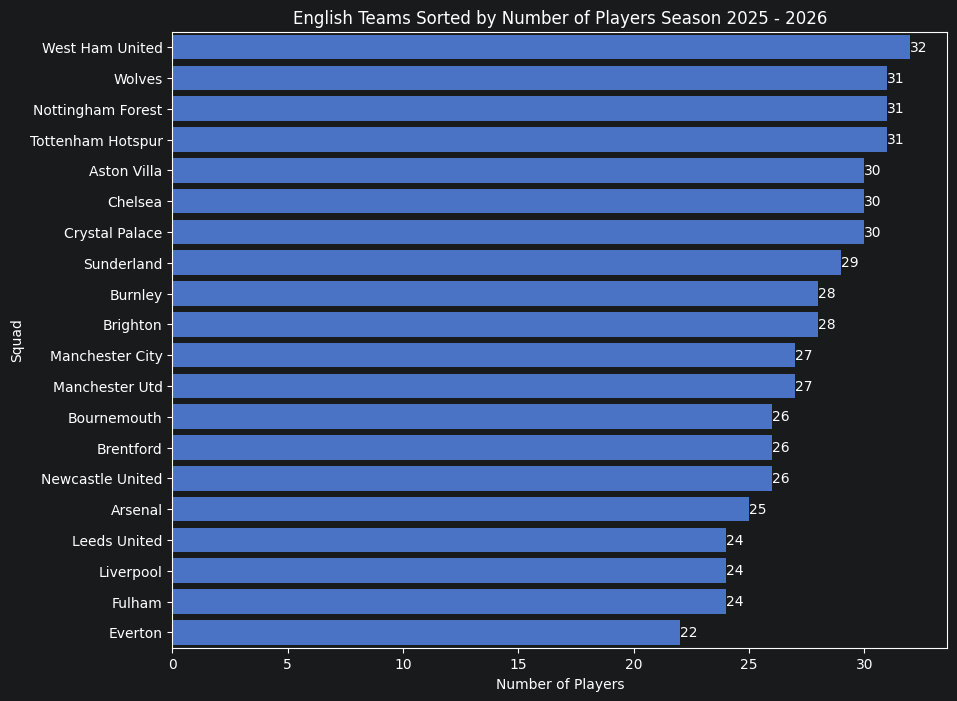

In [34]:
plt.figure(figsize= (10,8))

ax = sns.barplot(
    data= english_teams_players_count,
    y = "Squad",
    x = "Number of Players",
)

plt.title("English Teams Sorted by Number of Players Season 2025 - 2026")
plt.xlabel("Number of Players")
plt.ylabel("Squad")

for container in ax.containers:
    ax.bar_label(container)

plt.show()


In [35]:
english_teams_goals_scores = (
    english_teams
    .groupby("Squad", as_index= False)["Gls"]
    .sum()
    .sort_values("Gls", ascending= False)
)

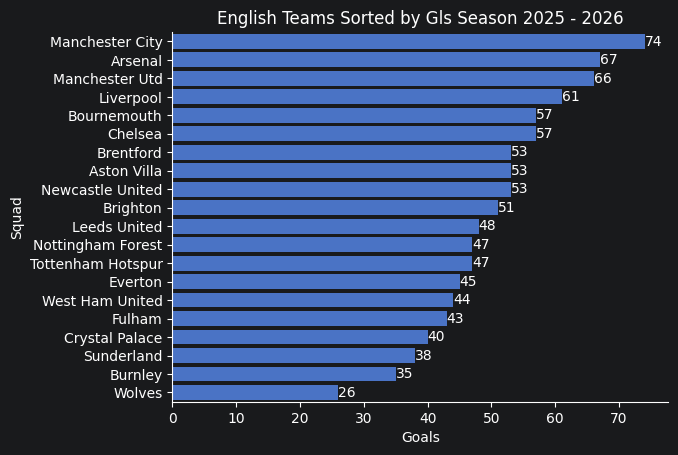

In [36]:
ax = sns.barplot(data= english_teams_goals_scores,
            x= "Gls",
            y= "Squad",
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("English Teams Sorted by Gls Season 2025 - 2026")
plt.xlabel("Goals")

sns.despine()
plt.show()

In [37]:
english_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

In [38]:
english_teams_assists = (
    english_teams
    .groupby("Squad", as_index= False)["Ast"]
    .sum()
    .sort_values("Ast", ascending= False)
    .reset_index(drop= True)
)
english_teams_assists

,Squad,Ast
0,Manchester City,57
1,Arsenal,51
2,Manchester Utd,46
3,Liverpool,44
4,Aston Villa,40
5,Chelsea,39
6,Tottenham Hotspur,36
7,Bournemouth,35
8,Everton,34
9,Nottingham Forest,34


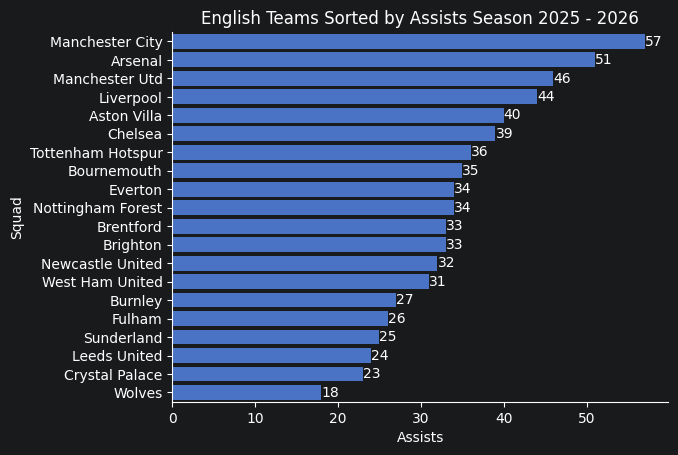

In [39]:
ax = sns.barplot(
    data= english_teams_assists,
    x= "Ast",
    y= "Squad",
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("English Teams Sorted by Assists Season 2025 - 2026")
plt.xlabel("Assists")
sns.despine()
plt.show()

In [40]:
english_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

# German Teams

In [41]:
german_teams = (
    players_df[
        players_df["Comp"].str.contains("Bundes")
    ]
)
german_teams

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,Save%,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm
20,21,Ragnar Ache,de GER,FW,Köln,de Bundesliga,27,1998,29,18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,26,Junior Adamu,at AUT,FW,Freiburg,de Bundesliga,24,2001,9,7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,29,Karim Adeyemi,de GER,"MF,FW",Dortmund,de Bundesliga,23,2002,28,15,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
32,33,Jonas Adjetey,gh GHA,DF,Wolfsburg,de Bundesliga,21,2003,4,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38,39,Dapo Afolayan,ng ENG,MF,St Pauli,de Bundesliga,27,1997,7,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2819,2820,Robin Zentner,de GER,GK,Mainz 05,de Bundesliga,30,1994,10,10,...,68.9,1.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0
2821,2822,Cedric Zesiger,ch SUI,DF,Augsburg,de Bundesliga,27,1998,27,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2822,2823,Michael Zetterer,de GER,GK,Eintracht Frankfurt,de Bundesliga,30,1995,22,21,...,66.7,8.0,7.0,6.0,6.0,28.6,2.0,2.0,0.0,0.0
2829,2830,Budu Zivzivadze,ge GEO,FW,Heidenheim,de Bundesliga,31,1994,20,14,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [42]:
german_teams_yellow_cards = (
    german_teams
    .groupby("Squad", as_index= False)["CrdY"]
    .sum()
    .sort_values("CrdY", ascending= False)
    .reset_index(drop= True)

)

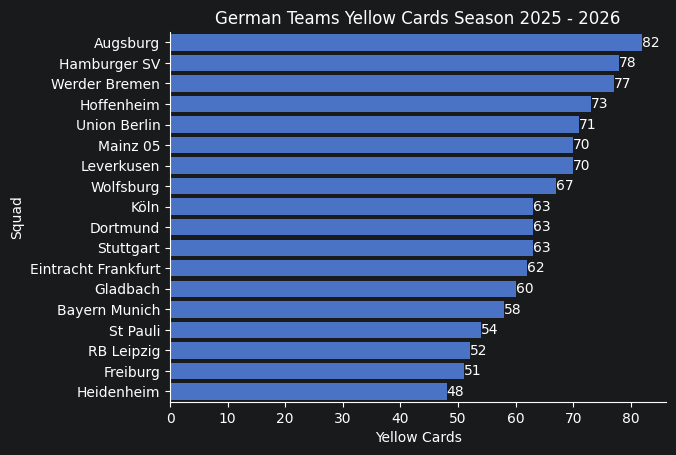

In [43]:
ax = sns.barplot(data= german_teams_yellow_cards,
            y = "Squad",
            x= "CrdY", )

for container in ax.containers:
    ax.bar_label(container)

plt.title("German Teams Yellow Cards Season 2025 - 2026")
plt.xlabel("Geman Teams")
plt.xlabel("Yellow Cards")
plt.ylabel("Squad")

sns.despine()
plt.show()

In [44]:
german_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

In [45]:
german_teams_red_cards_per_game = (
    german_teams
    .groupby("Squad")
    .agg({
        "CrdR": "sum",
        "MP": "max"
    })
)

german_teams_red_cards_per_game["Red Cards per Game"] = (
    german_teams_red_cards_per_game["CrdR"] / german_teams_red_cards_per_game["MP"]
)

german_teams_red_cards_per_game = (
    german_teams_red_cards_per_game
    .sort_values("Red Cards per Game", ascending= False)
)
german_teams_red_cards_per_game

,CrdR,MP,Red Cards per Game
Squad,,,
Hamburger SV,8,33,0.242424
Mainz 05,5,34,0.147059
Werder Bremen,5,34,0.147059
Eintracht Frankfurt,4,33,0.121212
Union Berlin,3,34,0.088235
Hoffenheim,3,34,0.088235
Köln,3,34,0.088235
Freiburg,3,34,0.088235
Gladbach,3,34,0.088235


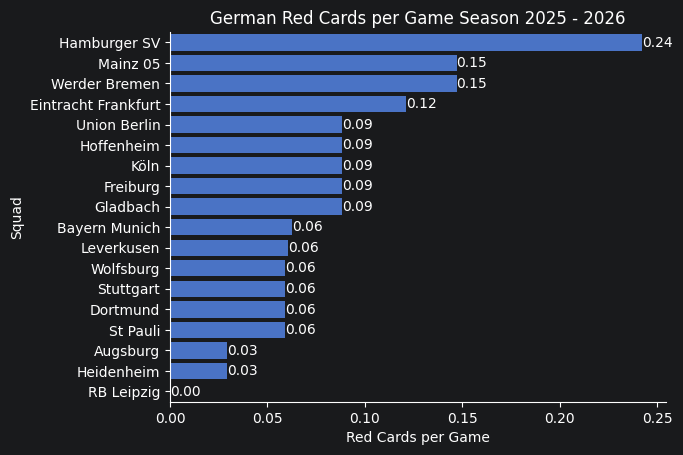

In [46]:
ax = sns.barplot(data= german_teams_red_cards_per_game,
            x= "Red Cards per Game",
            y= "Squad",)

for container in ax.containers:
    ax.bar_label(container, fmt= "%.2f")

plt.title("German Red Cards per Game Season 2025 - 2026")
sns.despine()
plt.show()

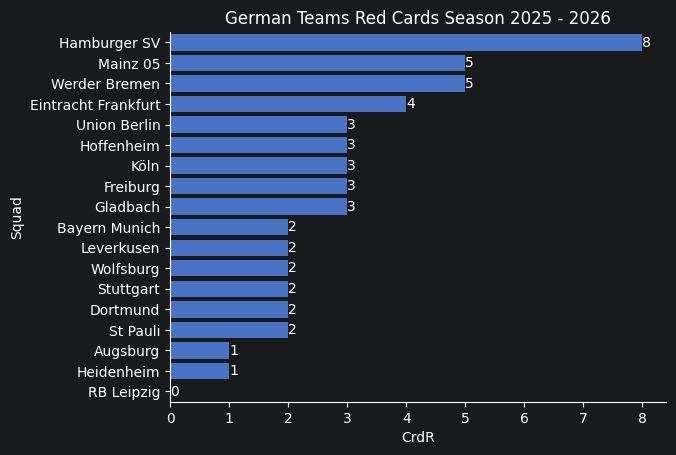

In [47]:
ax = sns.barplot(data= german_teams_red_cards_per_game,
            x= "CrdR",
            y= "Squad",)

for container in ax.containers:
    ax.bar_label(container)

plt.title("German Teams Red Cards Season 2025 - 2026")

sns.despine()
plt.show()

In [48]:
german_teams_goals_scores = (
    german_teams
    .groupby(["Squad"], as_index= False)["Gls"]
    .sum()
    .sort_values("Gls", ascending= False)
    .reset_index(drop= True)
)


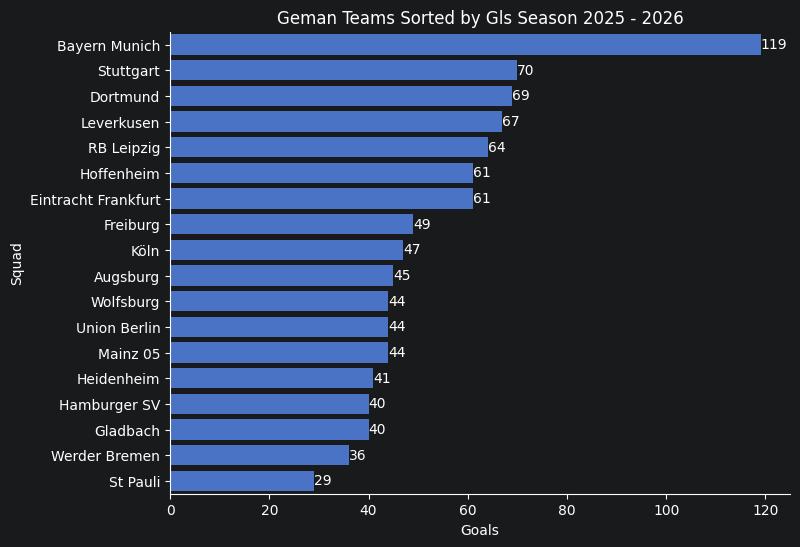

In [49]:
plt.figure(figsize= (8,6))

ax = sns.barplot(data= german_teams_goals_scores,
            x = "Gls",
            y= "Squad",)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Geman Teams Sorted by Gls Season 2025 - 2026")
plt.xlabel("Goals")

sns.despine()
plt.show()

In [50]:
german_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

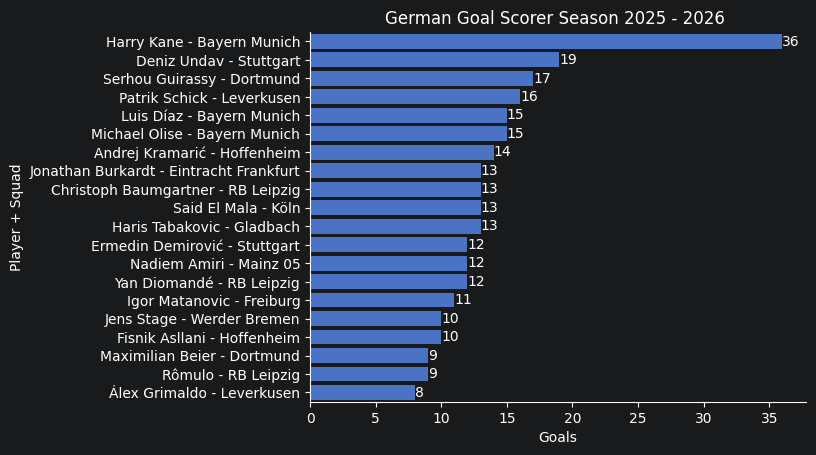

In [51]:
german_teams_scorer = (
    german_teams
    .groupby(["Squad", "Player"], as_index= False)
    .agg({
        "Player": "sum",
        "Gls": "sum",
        "Ast": "sum"
    })
    .rename(columns={"Player": "Player Name",
                     "Gls": "Goals",
                     "Ast": "Assists",
                     })
    .sort_values("Goals", ascending= False)
    .reset_index(drop= True)
)

german_teams_scorer["Player + Squad"] = (
    german_teams_scorer["Player Name"] + " - " + german_teams_scorer["Squad"]
)

ax = sns.barplot(data= german_teams_scorer.head(20),
            x= "Goals",
            y= "Player + Squad",)

for container in ax.containers:
    ax.bar_label(container)

plt.title("German Goal Scorer Season 2025 - 2026 ")

sns.despine()
plt.show()

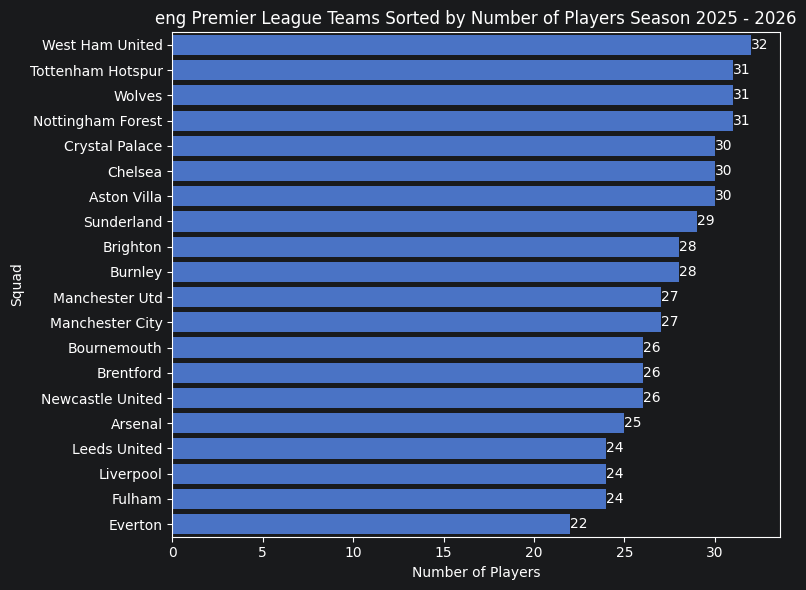

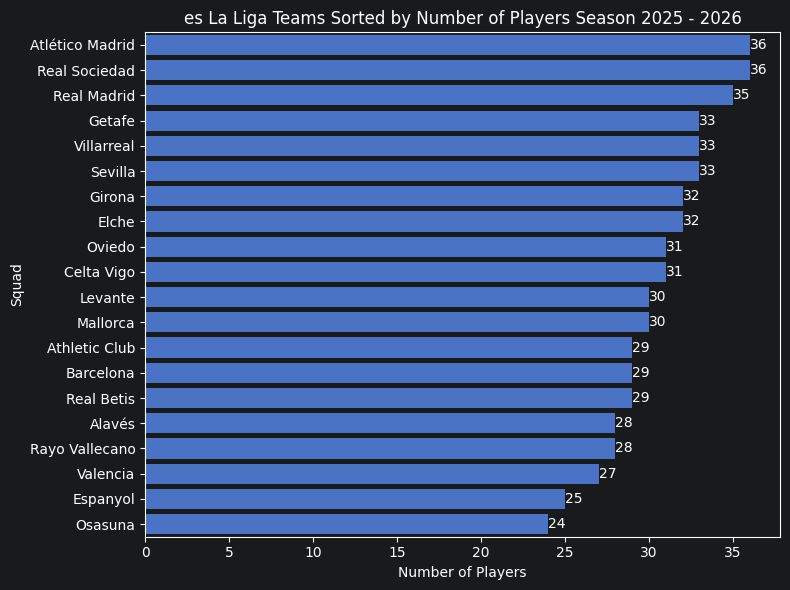

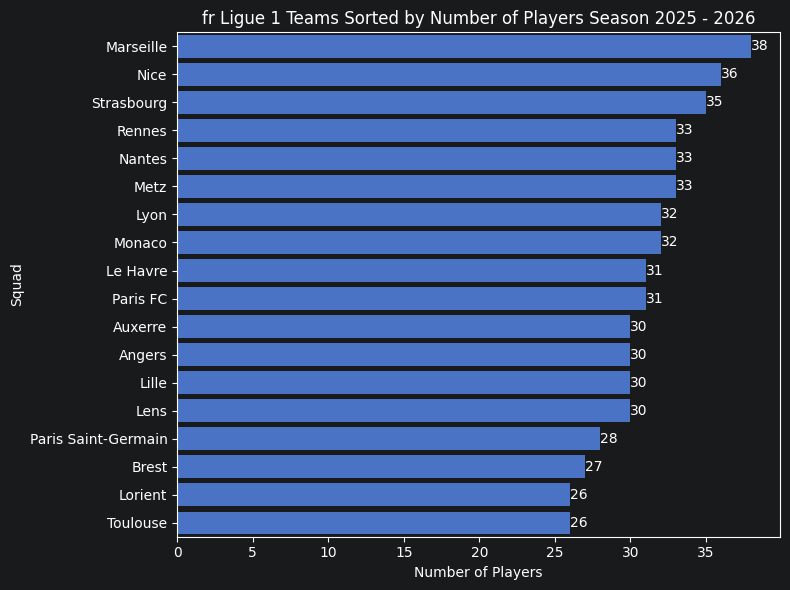

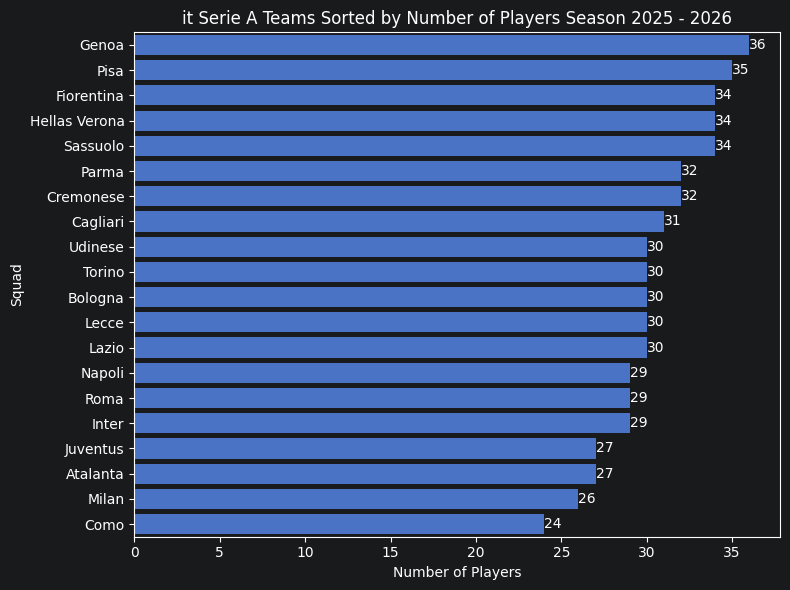

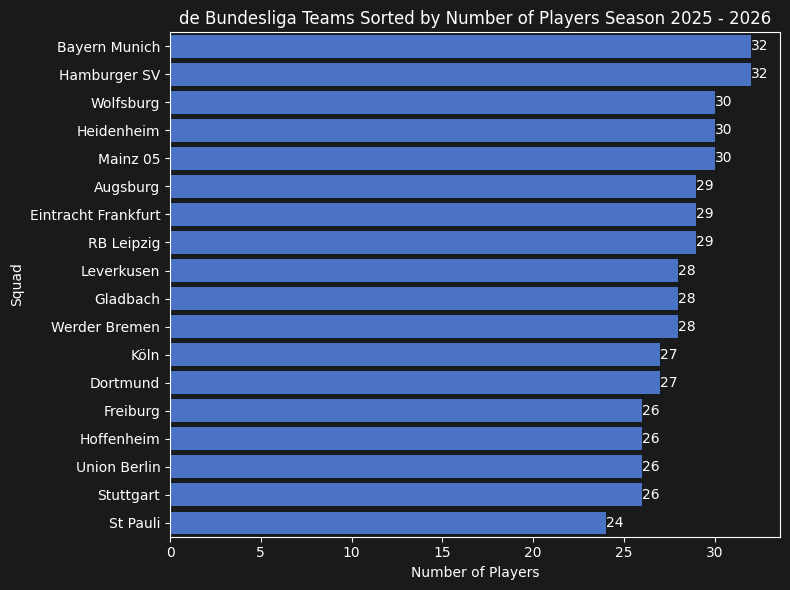

In [52]:
for comp in players_df["Comp"].unique():

    comp_players = players_df[
        players_df["Comp"] == comp
    ]

    comp_players_count = (
        comp_players
        .groupby("Squad", as_index=False)
        .size()
        .rename(columns={"size": "Number of Players"})
        .sort_values("Number of Players", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(8, 6))

    ax = sns.barplot(
        data=comp_players_count,
        y="Squad",
        x="Number of Players"
    )

    for container in ax.containers:
        ax.bar_label(container)

    plt.title(f"{comp} Teams Sorted by Number of Players Season 2025 - 2026")
    plt.xlabel("Number of Players")
    plt.ylabel("Squad")

    plt.tight_layout()
    plt.show()

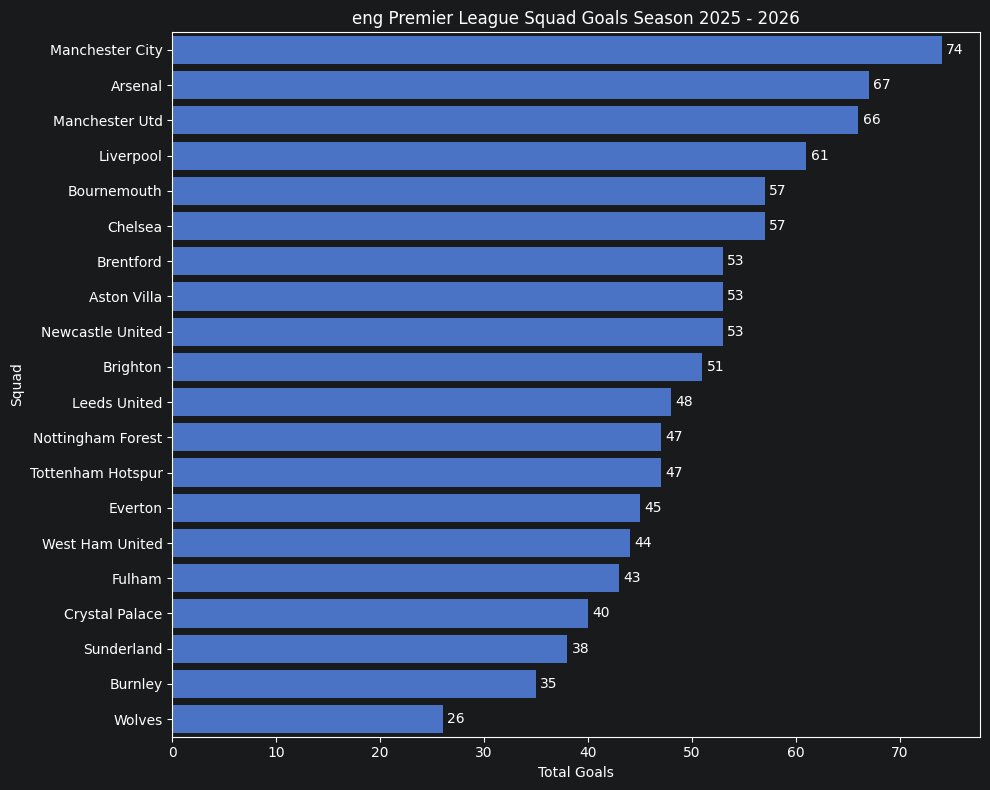

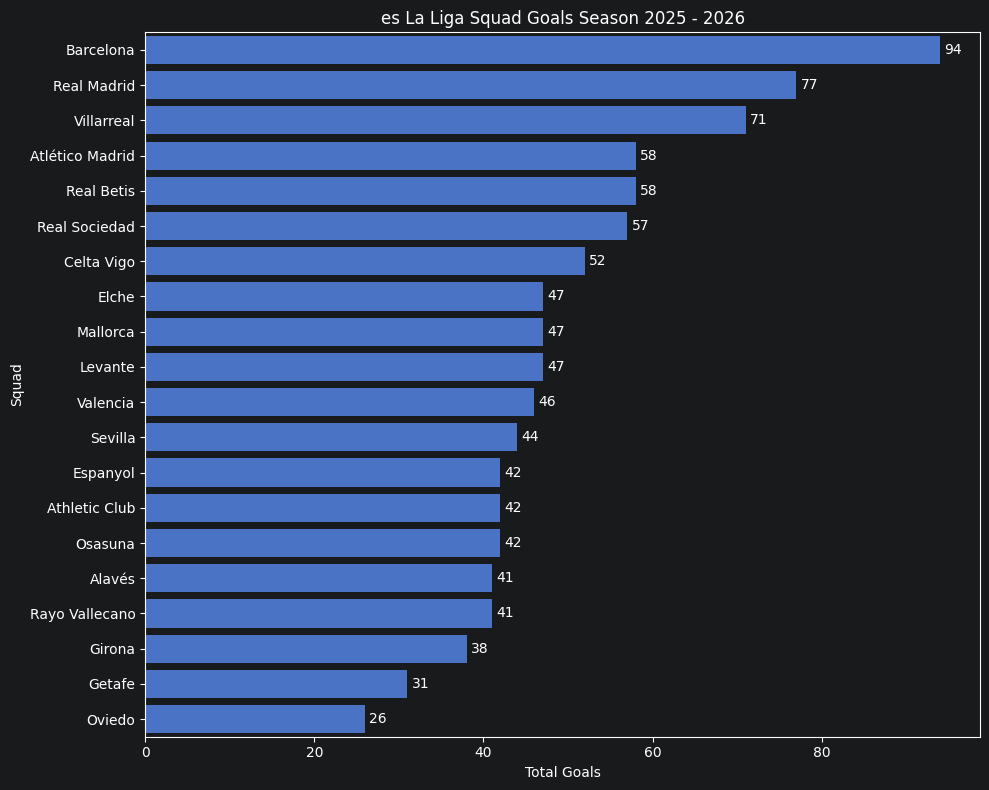

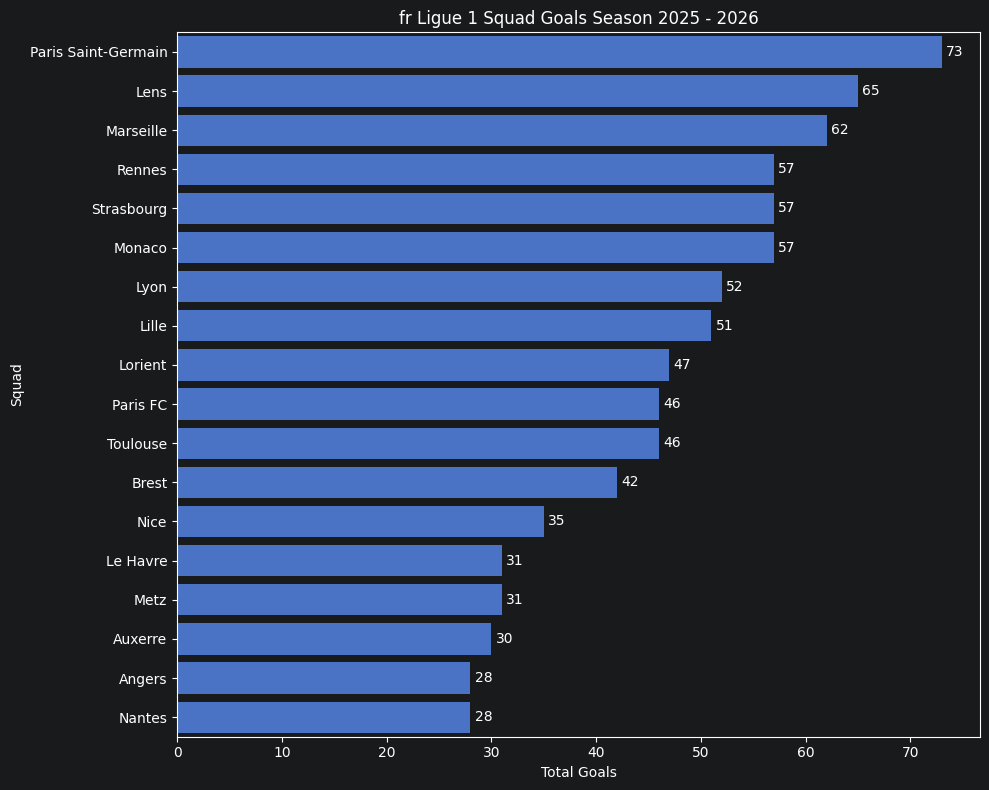

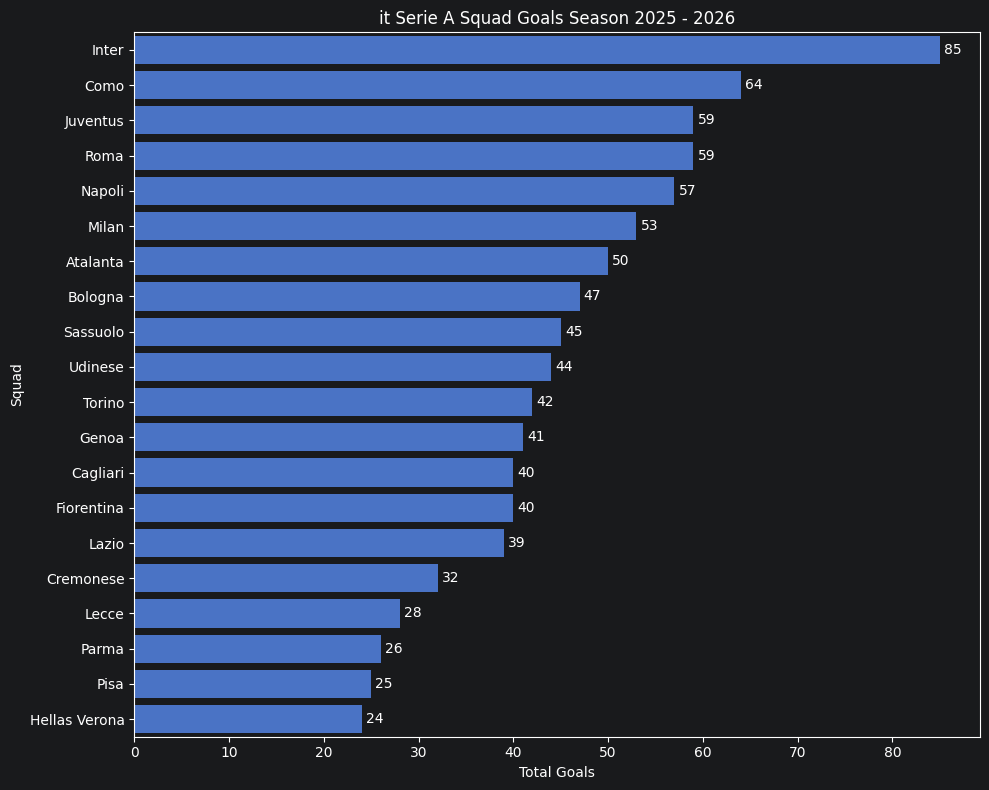

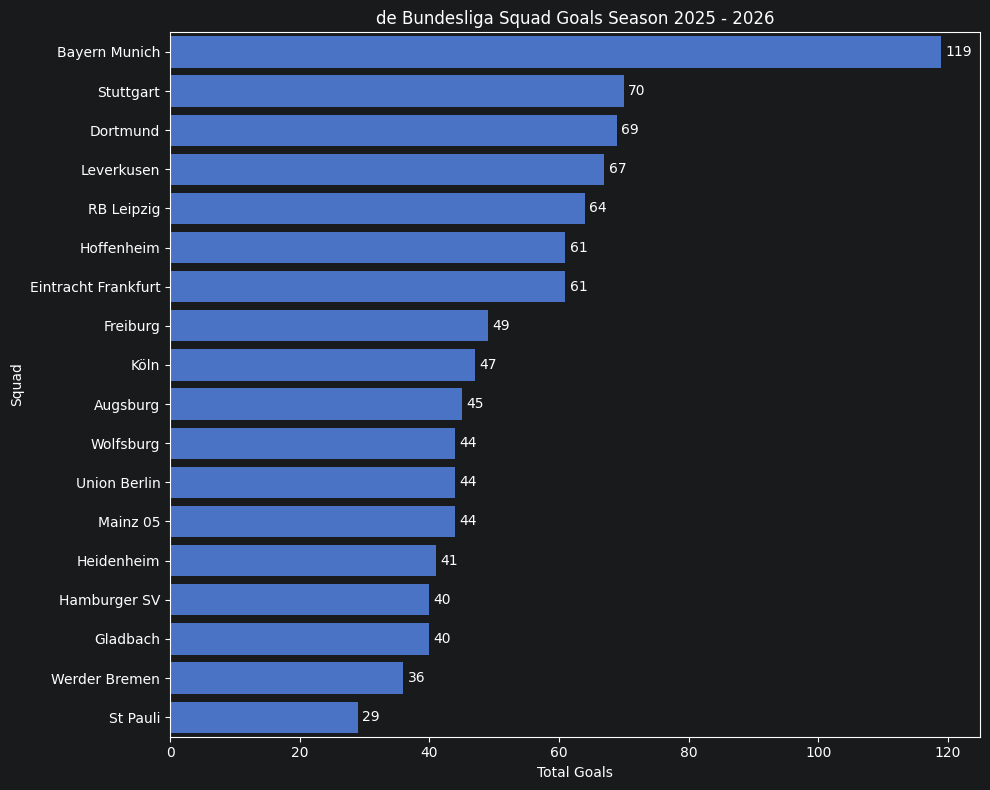

In [53]:
for comp in players_df["Comp"].dropna().unique():

    comp_squad_goals = (
        players_df[players_df["Comp"] == comp]
        .groupby("Squad", as_index=False)["Gls"]
        .sum()
        .sort_values("Gls", ascending=False)
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, 8))

    ax = sns.barplot(
        data=comp_squad_goals,
        x="Gls",
        y="Squad"
    )

    plt.title(f"{comp} Squad Goals Season 2025 - 2026")
    plt.xlabel("Total Goals")
    plt.ylabel("Squad")

    for container in ax.containers:
        ax.bar_label(container, padding=3)

    plt.tight_layout()
    plt.show()

In [54]:
players_df["Mean Age"] = players_df["Age"]

In [55]:
league_summary = (
    players_df
    .groupby("Comp", as_index=False)
    .agg({
        "Gls": "sum",
        "Ast": "sum",
        "CrdY": "sum",
        "CrdR": "sum",
        "Age": "mean"
    })
    .rename(columns={
        "Comp": "Competition",
        "Gls": "Goals",
        "Ast": "Assists",
        "CrdY": "Yellow Cards",
        "CrdR": "Red Cards",
        "Age": "Mean Age"
    })
).sort_values("Goals", ascending= False)
league_summary

,Competition,Goals,Assists,Yellow Cards,Red Cards,Mean Age
1,eng Premier League,1005,688,1452,44,24.85118
2,es La Liga,1001,700,1676,105,25.434426
0,de Bundesliga,970,697,1162,51,24.676529
4,it Serie A,900,611,1407,68,25.266447
3,fr Ligue 1,838,595,1153,76,23.948307


In [56]:
league_summary

,Competition,Goals,Assists,Yellow Cards,Red Cards,Mean Age
1,eng Premier League,1005,688,1452,44,24.85118
2,es La Liga,1001,700,1676,105,25.434426
0,de Bundesliga,970,697,1162,51,24.676529
4,it Serie A,900,611,1407,68,25.266447
3,fr Ligue 1,838,595,1153,76,23.948307


In [57]:
# Rename only if these columns exist
league_summary = league_summary.rename(columns={
    "Comp": "Competition",
    "Gls": "Goals",
    "Ast": "Assists",
    "CrdY": "Yellow Cards",
    "CrdR": "Red Cards",
    "Age": "Mean Age"
})

print(league_summary.columns)

Index(['Competition', 'Goals', 'Assists', 'Yellow Cards', 'Red Cards',
       'Mean Age'],
      dtype='str')


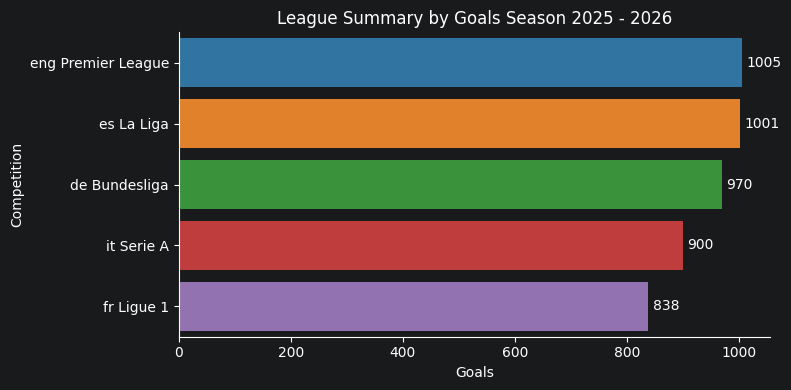

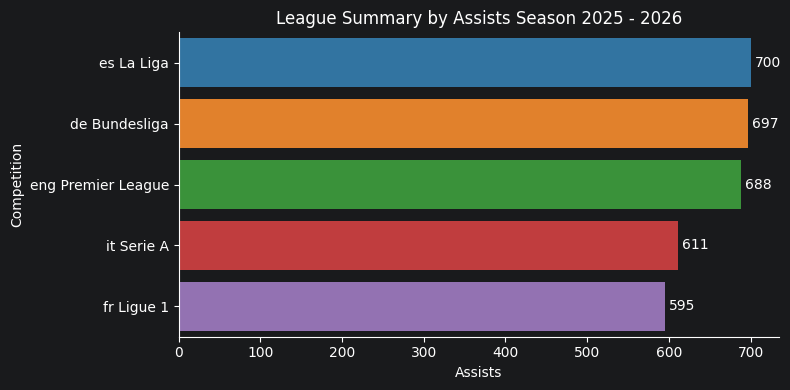

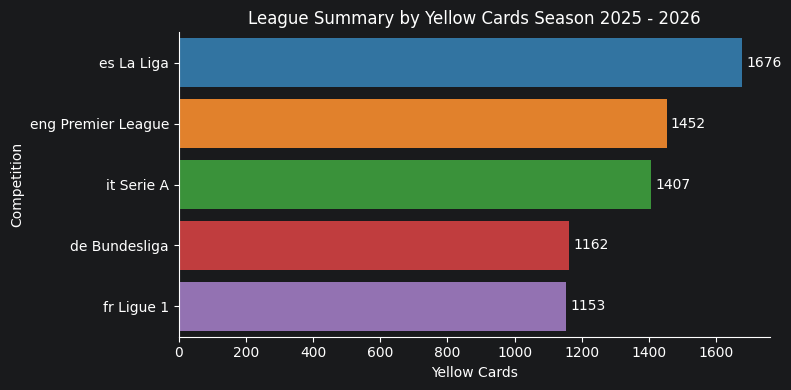

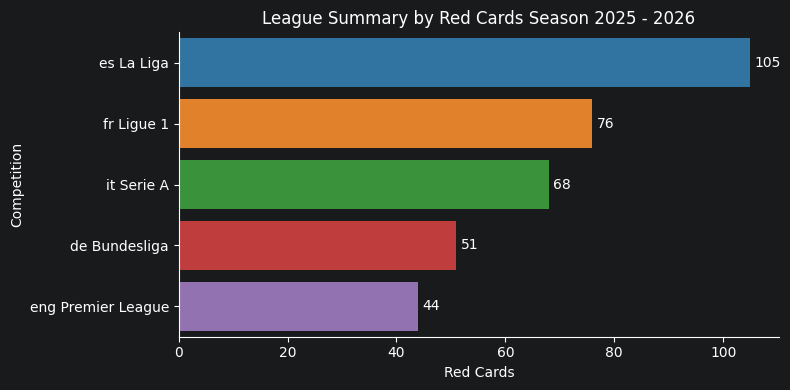

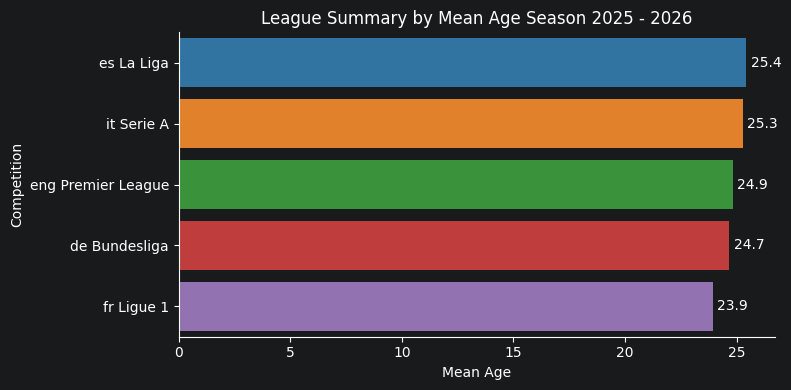

In [58]:
plot_columns = [
    "Goals",
    "Assists",
    "Yellow Cards",
    "Red Cards",
    "Mean Age"
]

for c in plot_columns:

    plot_data = league_summary.sort_values(c, ascending=False)

    plt.figure(figsize=(8, 4))

    ax = sns.barplot(
        data=plot_data,
        x=c,
        y="Competition",
        hue="Competition",
        palette="tab10",
        legend=False
    )

    label_format = "%.1f" if c == "Mean Age" else "%.0f"

    for container in ax.containers:
        ax.bar_label(container, fmt=label_format, padding=3)

    plt.title(f"League Summary by {c} Season 2025 - 2026")
    plt.xlabel(c)
    plt.ylabel("Competition")

    sns.despine()
    plt.tight_layout()
    plt.show()

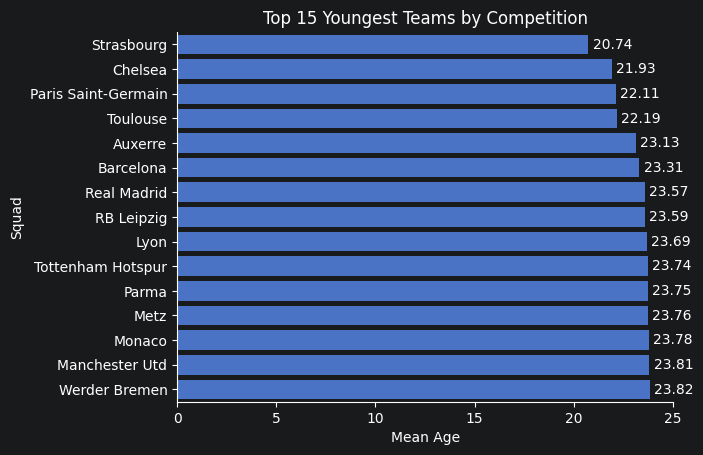

In [59]:
youngest_teams_by_competition = (
    players_df
    .groupby(["Comp", "Squad"], as_index= False)["Mean Age"]
    .mean()
    .sort_values(["Mean Age"], ascending= True)
    .reset_index(drop= True)
)


ax = sns.barplot(data=youngest_teams_by_competition.head(15),
            x="Mean Age",
            y="Squad", )

for container in ax.containers:
    ax.bar_label(container, padding=3, fmt="%.2f")

plt.title("Top 15 Youngest Teams by Competition")
plt.xlabel("Mean Age")

sns.despine()
plt.show()

In [60]:
german_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm'],
      dtype='str')

In [61]:
league_summary.columns

Index(['Competition', 'Goals', 'Assists', 'Yellow Cards', 'Red Cards',
       'Mean Age'],
      dtype='str')

In [62]:
league_summary.columns

Index(['Competition', 'Goals', 'Assists', 'Yellow Cards', 'Red Cards',
       'Mean Age'],
      dtype='str')

In [63]:
players_df.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Mean Age'],
      dtype='str')

In [64]:
8/44


0.18181818181818182

# Champion League Season 2025- 2026

In [65]:
europa_league_df = pd.read_csv("data/Top Goal Scorer Champions League 2025-2026.csv",
                                  sep= ";",
                                  header= 1)
europa_league_df

,Player,Span,Nation,Pos,Squad,MP,Starts,Min,90s,Gls,...,G-PK,PK,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK
0,Kylian Mbappé,2025-26,fr FRA,FW,Real Madrid,11,10,912,10.1,15,...,12,3,3,2,0,1.48,0.10,1.58,1.18,1.28
1,Harry Kane,2025-26,eng ENG,FW,Bayern Munich,13,12,"1,036",11.5,14,...,10,4,5,0,0,1.22,0.17,1.39,0.87,1.04
2,Julián Álvarez,2025-26,ar ARG,FW,Atlético Madrid,15,15,"1,234",13.7,10,...,7,3,3,0,0,0.73,0.29,1.02,0.51,0.80
3,Anthony Gordon,2025-26,eng ENG,FW,Newcastle United,12,9,767,8.5,10,...,5,5,5,1,0,1.17,0.23,1.41,0.59,0.82
4,Khvicha Kvaratskhelia,2025-26,ge GEO,FW,Paris Saint-Germain,16,14,"1,134",12.6,10,...,10,0,0,3,0,0.79,0.48,1.27,0.79,1.27
5,Erling Haaland,2025-26,no NOR,FW,Manchester City,10,9,751,8.3,8,...,7,1,1,0,0,0.96,0.00,0.96,0.84,0.84


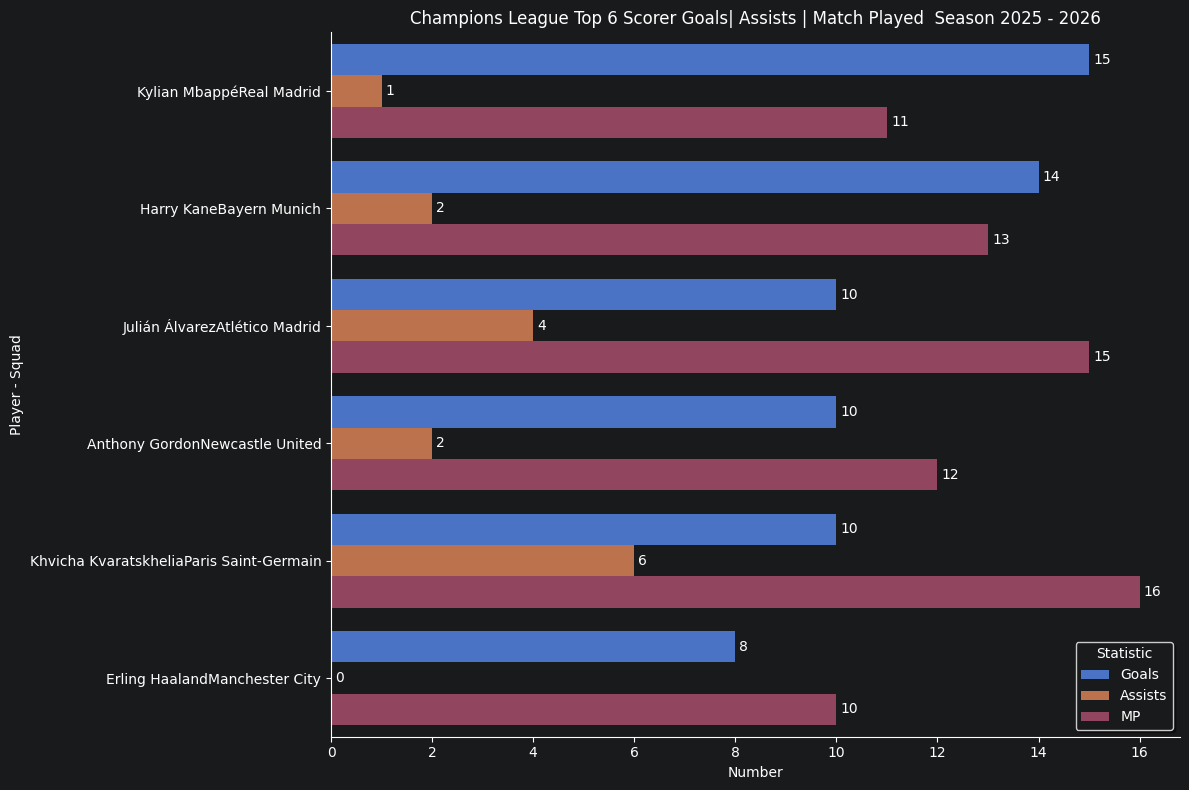

In [66]:
europa_league_df["Player + Squad"] = (
    europa_league_df["Player"] + europa_league_df["Squad"]
)

europa_league_goal_scorer = (
    europa_league_df
    .groupby(["Player + Squad", "MP"], as_index=False)
    .agg({
        "Gls": "sum",
        "Ast": "sum"
    })
    .sort_values("Gls", ascending=False)
    .reset_index(drop=True)
)


europa_league_goal_scorer["Player Info"] = (
        europa_league_goal_scorer["Player + Squad"]
        + " - " +
        europa_league_goal_scorer["MP"].astype(str)
)

top_6_ucl_scorers = europa_league_goal_scorer.head(6)

plot_data = top_6_ucl_scorers.melt(
    id_vars="Player + Squad",
    value_vars=["Gls", "Ast", "MP"],
    var_name="Stat",
    value_name="Value"
)

plt.figure(figsize=(12, 8))

plot_data["Stat"] = plot_data["Stat"].replace({
    "Gls": "Goals",
    "Ast": "Assists"
})

ax = sns.barplot(
    data=plot_data,
    x="Value",
    y="Player + Squad",
    hue="Stat",
)

plt.title("Champions League Top 6 Scorer Goals| Assists | Match Played  Season 2025 - 2026")
plt.xlabel("Number")
plt.ylabel("Player - Squad")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(
    title = "Statistic",
    loc="lower right",
    frameon=True,
    fancybox=True,
    shadow=True,
)

sns.despine()
plt.tight_layout()
plt.show()

# Europa League Season 2025 - 2026

In [67]:
europa_league_df = pd.read_csv("data/Europa League Season 2026 - 2026.csv", sep= ";", header= 1)
europa_league_df

,Player,Span,Nation,Pos,Squad,MP,Starts,Min,90s,Gls,...,G-PK,PK,PKatt,CrdY,CrdR,Gls.1,Ast.1,G+A.1,G-PK.1,G+A-PK
0,Petar Stanic,2025-26,rs SRB,"MF,FW",Ludogorets Razgrad,10,10,856,9.5,7,...,4,3,3,1,0,0.74,0.11,0.84,0.42,0.53
1,Igor Jesus,2025-26,br BRA,"FW,MF",Nottingham Forest,13,8,793,8.8,7,...,6,1,1,4,0,0.79,0.11,0.91,0.68,0.79
2,Antony,2025-26,br BRA,"MF,FW",Real Betis,10,9,785,8.7,6,...,6,0,0,2,0,0.69,0.34,1.03,0.69,1.03
3,Kerem Aktürkoğlu,2025-26,tr TUR,"MF,FW",Fenerbahçe,9,9,695,7.7,6,...,4,2,2,1,0,0.78,0.13,0.91,0.52,0.65
4,Williot Swedberg,2025-26,se SWE,"FW,MF",Celta Vigo,10,8,579,6.4,5,...,5,0,0,4,0,0.78,0.31,1.09,0.78,1.09
5,Vincenzo Grifo,2025-26,it ITA,MF,Freiburg,15,14,966,10.7,5,...,4,1,1,3,0,0.47,0.37,0.84,0.37,0.75


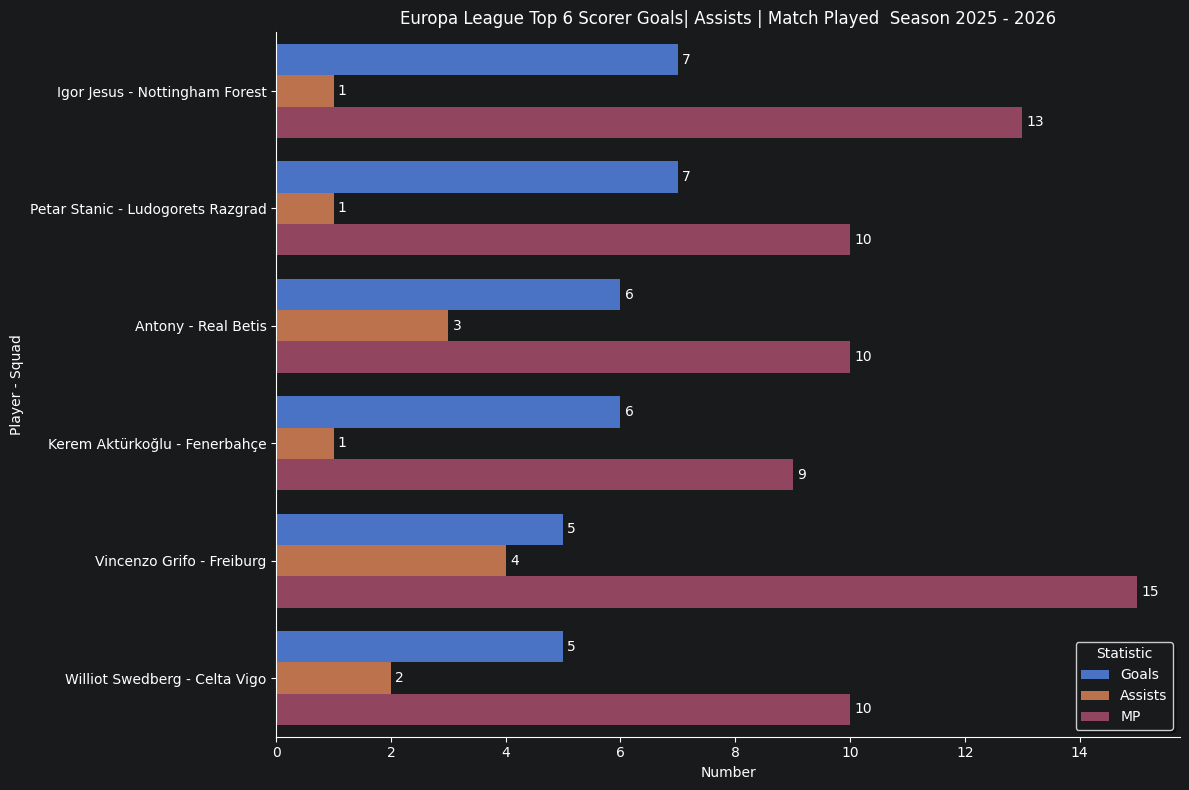

In [68]:
europa_league_df["Player + Squad"] = (
    europa_league_df["Player"]
    + " - " +
    europa_league_df["Squad"]
)

europa_league_goal_scorer = (
    europa_league_df
    .groupby(["Player + Squad", "MP"], as_index=False)
    .agg({
        "Gls": "sum",
        "Ast": "sum"
    })
    .sort_values("Gls", ascending=False)
    .reset_index(drop=True)
)


europa_league_df["Player Info"] = (
        europa_league_goal_scorer["Player + Squad"]
        + " - " +
        europa_league_goal_scorer["MP"].astype(str)
)

top_6_ucl_scorers = europa_league_goal_scorer.head(6)

plot_data = top_6_ucl_scorers.melt(
    id_vars="Player + Squad",
    value_vars=["Gls", "Ast", "MP"],
    var_name="Stat",
    value_name="Value"
)

plt.figure(figsize=(12, 8))

plot_data["Stat"] = plot_data["Stat"].replace({
    "Gls": "Goals",
    "Ast": "Assists"
})

ax = sns.barplot(
    data=plot_data,
    x="Value",
    y="Player + Squad",
    hue="Stat",
)

plt.title("Europa League Top 6 Scorer Goals| Assists | Match Played  Season 2025 - 2026")
plt.xlabel("Number")
plt.ylabel("Player - Squad")

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(
    title = "Statistic",
    loc= "lower right",
    frameon= True,
    fancybox= True,
    shadow= True,
)

sns.despine()
plt.tight_layout()
plt.show()

## Best Goalkeepers

In [69]:
goalkeepers = players_df[
    players_df["Pos"].str.contains("GK", case=False, na=False)
].copy()

best_goalkeepers = goalkeepers[[
    "Player", "Squad", "Comp", "Nation", "MP", "Saves", "Save%", "CS", "GA90"
]].sort_values("Saves", ascending= False).reset_index(drop=True)

In [70]:
best_goalkeepers

,Player,Squad,Comp,Nation,MP,Saves,Save%,CS,GA90
0,Aarón Escandell,Oviedo,es La Liga,es ESP,36,145.0,73.7,10.0,1.56
1,Moritz Nicolas,Gladbach,de Bundesliga,de GER,34,136.0,73.9,13.0,1.56
2,Marko Dmitrović,Espanyol,es La Liga,rs SRB,37,133.0,73.1,10.0,1.46
3,Martin Dúbravka,Burnley,eng Premier League,sk SVK,35,127.0,66.1,4.0,2.03
4,Mathew Ryan,Levante,es La Liga,au AUS,36,124.0,69.9,9.0,1.56
...,...,...,...,...,...,...,...,...,...
189,Kjetil Haug,Toulouse,fr Ligue 1,no NOR,1,1.0,50.0,0.0,2.90
190,Angus Gunn,Nottingham Forest,eng Premier League,ct SCO,1,0.0,NaN,0.0,0.00
191,Nikita Contini Baranovsky,Napoli,it Serie A,it ITA,1,0.0,NaN,1.0,0.00
192,Luca Lezzerini,Fiorentina,it Serie A,it ITA,1,0.0,NaN,0.0,0.00


In [71]:
goalkeepers_spain = (
    goalkeepers[
        goalkeepers["Nation"].str.contains("es", case=False, na=False)
    ]
).sort_values("Saves", ascending= False).reset_index(drop=True)
goalkeepers_spain[["Player", "Squad", "Nation", "Age", "MP", "Saves", "Save%", "CS", "GA90"]]

,Player,Squad,Nation,Age,MP,Saves,Save%,CS,GA90
0,Aarón Escandell,Oviedo,es ESP,29,36,145.0,73.7,10.0,1.56
1,David de Gea,Fiorentina,es ESP,34,37,119.0,73.0,10.0,1.32
2,David Soria,Getafe,es ESP,32,38,115.0,75.5,12.0,1.00
3,Sergio Herrera,Osasuna,es ESP,32,37,113.0,74.3,7.0,1.29
4,Leo Román,Mallorca,es ESP,25,33,99.0,69.0,4.0,1.52
5,Álex Remiro,Real Sociedad,es ESP,30,37,99.0,64.3,3.0,1.62
6,Unai Simón,Athletic Club,es ESP,28,37,97.0,65.1,6.0,1.46
7,Antonio Sivera,Alavés,es ESP,28,38,97.0,65.5,5.0,1.47
8,Robert Sánchez,Chelsea,es ESP,27,35,97.0,67.6,9.0,1.45
9,Álvaro Vallés,Real Betis,es ESP,28,28,87.0,72.9,8.0,1.29


# Midfielders

In [72]:
france_teams = (
    players_df[
        players_df["Nation"].str.contains("fr", case=False, na=False)
    ]
)
france_teams

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Mean Age
10,11,Laurent Abergel,fr FRA,MF,Lorient,fr Ligue 1,32,1993,28,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32
11,12,Matthis Abline,fr FRA,"FW,MF",Nantes,fr Ligue 1,22,2003,33,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
41,42,Lucien Agoume,fr FRA,MF,Sevilla,es La Liga,23,2002,34,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
48,49,Ruben Aguilar,fr FRA,MF,Lens,fr Ligue 1,32,1993,26,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32
50,51,Naouirou Ahamada,fr FRA,MF,Auxerre,fr Ligue 1,23,2002,15,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,Etienne Youte Kinkoue,fr FRA,"DF,MF",Le Havre,fr Ligue 1,23,2002,9,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
2801,2802,Dan-Axel Zagadou,fr FRA,DF,Stuttgart,de Bundesliga,26,1999,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26
2802,2803,Stephan Zagadou,fr FRA,DF,Le Havre,fr Ligue 1,16,2008,8,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
2803,2804,Warren Zaïre-Emery,fr FRA,"DF,MF",Paris Saint-Germain,fr Ligue 1,19,2006,32,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19


In [73]:
france_teams

,Rk,Player,Nation,Pos,Squad,Comp,Age,Born,MP,Starts,...,W,D,L,CS,CS%,PKatt_stats_keeper,PKA,PKsv,PKm,Mean Age
10,11,Laurent Abergel,fr FRA,MF,Lorient,fr Ligue 1,32,1993,28,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32
11,12,Matthis Abline,fr FRA,"FW,MF",Nantes,fr Ligue 1,22,2003,33,28,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22
41,42,Lucien Agoume,fr FRA,MF,Sevilla,es La Liga,23,2002,34,31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
48,49,Ruben Aguilar,fr FRA,MF,Lens,fr Ligue 1,32,1993,26,20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32
50,51,Naouirou Ahamada,fr FRA,MF,Auxerre,fr Ligue 1,23,2002,15,8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,2796,Etienne Youte Kinkoue,fr FRA,"DF,MF",Le Havre,fr Ligue 1,23,2002,9,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23
2801,2802,Dan-Axel Zagadou,fr FRA,DF,Stuttgart,de Bundesliga,26,1999,3,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,26
2802,2803,Stephan Zagadou,fr FRA,DF,Le Havre,fr Ligue 1,16,2008,8,6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16
2803,2804,Warren Zaïre-Emery,fr FRA,"DF,MF",Paris Saint-Germain,fr Ligue 1,19,2006,32,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19


In [74]:
attacking_midfielders_france = (
    france_teams
    .groupby("Player",as_index= False)
    .sum()
    .sort_values("Gls", ascending= False)
    .reset_index(drop=True)
)
print(attacking_midfielders_france[["Player", "Squad", "Nation", "Pos", "Age", "MP", "Gls", "Ast"]])

                 Player          Squad        Nation    Pos  Age  MP  Gls  Ast
0         Kylian Mbappé    Real Madrid        fr FRA     FW   26  31   25    5
1        Esteban Lepaul   AngersRennes  fr FRAfr FRA   FWFW   50  34   21    5
2         Michael Olise  Bayern Munich        fr FRA     MF   23  32   15   19
3     Eli Junior Kroupi    Bournemouth        fr FRA  MF,FW   19  33   13    0
4         Marcus Thuram          Inter        fr FRA     FW   27  29   13    6
..                  ...            ...           ...    ...  ...  ..  ...  ...
307    Tyrese Noubissié     Strasbourg        fr FRA     MF   16   4    0    0
308  Aboubaka Soumahoro   Hamburger SV        fr FRA  MF,DF   20   4    0    0
309   Yassine Benhattab         Nantes        fr FRA  MF,FW   22  10    0    0
310    Abdoulaye Camara        Udinese        fr FRA     MF   16   1    0    0
311      Zoumana Diallo           Nice        fr FRA     FW   20   1    0    0

[312 rows x 8 columns]


In [75]:
france_teams.columns

Index(['Rk', 'Player', 'Nation', 'Pos', 'Squad', 'Comp', 'Age', 'Born', 'MP',
       'Starts', 'Min', '90s', 'Gls', 'Ast', 'G+A', 'G-PK', 'PK', 'PKatt',
       'CrdY', 'CrdR', 'G+A-PK', 'Sh', 'SoT', 'SoT%', 'Sh/90', 'SoT/90',
       'G/Sh', 'G/SoT', 'PK_stats_shooting', 'PKatt_stats_shooting', 'Crs',
       'TklW', 'Int', 'Fld', 'CrdY_stats_misc', 'CrdR_stats_misc', '2CrdY',
       'Fls', 'OG', 'GA', 'GA90', 'SoTA', 'Saves', 'Save%', 'W', 'D', 'L',
       'CS', 'CS%', 'PKatt_stats_keeper', 'PKA', 'PKsv', 'PKm', 'Mean Age'],
      dtype='str')

In [77]:
print(players_df)

        Rk               Player  Nation    Pos              Squad  \
0        1     Brenden Aaronson  us USA  MF,FW       Leeds United   
1        2         Jerome Abbey  ng ENG     MF             Wolves   
2        3          Zach Abbott  ng ENG     DF  Nottingham Forest   
3        4  Jones El-Abdellaoui  ma MAR  MF,FW         Celta Vigo   
4        5        Himad Abdelli  dz ALG     MF          Marseille   
...    ...                  ...     ...    ...                ...   
2834  2835     Martín Zubimendi  es ESP     MF            Arsenal   
2835  2836      Martin Ødegaard  no NOR     MF            Arsenal   
2836  2837           Luka Đurić  rs SRB     MF         Hoffenheim   
2837  2838          Milan Đurić  ba BIH     FW          Cremonese   
2838  2839          Milan Đurić  ba BIH     FW              Parma   

                    Comp  Age  Born  MP  Starts  ...   W   D   L  CS  CS%  \
0     eng Premier League   24  2000  37      30  ... NaN NaN NaN NaN  NaN   
1     eng Premier